# Analyse des fichiers d'expérimentations

* Exécution successive (moyenne) : 10x
* CPUS : 8 CPUS-2.4 GHz
* Mémoire : 12Go

`hypothèses`:

* L'échantillonnage peut permettre d'améliorer la qualité des clusters issus de l'apprentissage par ensemble
* Combiner plusieurs algorithmes homogènes de clustering multi-vues, améliorerait la qualité des clusters

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Analyses globales

chargement des resultats

In [2]:
df_mcles = pd.read_csv("results/fine_tuning.mcles.msrcv1.csv")
df_mvgl = pd.read_csv("results/fine_tuning.mvgl.msrcv1.csv")

In [3]:
metrics = ["ACC", "NMI", "PUR"]
cmaps = {"ACC": "viridis", "NMI": "viridis", "PUR": "viridis"}

fonctions de construction de graphiques et tableaux utiles

In [4]:
from matplotlib import markers

def plot_metrics(df):
    for metric in metrics:
        ax0 = plt.axes(projection="3d")

        ax0.plot_trisurf(
            df["p"],
            df["nw"],
            df[metric],
            cmap=cmaps[metric],
            edgecolor=None,
        )

        ax0.set_title(metric)
        ax0.set_xlabel("p")
        ax0.set_ylabel("nw")
        plt.show()
        
        
def plot_fixed(df):
    data = pd.pivot_table(df, index=["p"], columns=["nw"])
    for metric in metrics:
        columns = data[metric].columns
        index = data[metric].index
        
        # affichage pour p
        fig = plt.figure()
        ax0 = fig.add_subplot(111)
        ax0.set_ylabel(metric)
        ax0.set_xlabel("p")
        for column in columns:
            ax0.plot(index, data[metric][column], label=f"nw = {column}", marker=markers.CARETRIGHT)
        ax0.legend()
        plt.show()
        
        # affichage pour nw
        fig = plt.figure()
        ax0 = fig.add_subplot(111)
        ax0.set_xlabel("nw")
        ax0.set_ylabel(metric)
        
        for i in range(len(index)):
            ax0.plot(columns, data[metric].iloc[i].to_list(), label=f"p = { round(index[i], 3) }", marker=markers.CARETRIGHT)
        
        ax0.legend()
        plt.show()


def pivot_tables(df, model):
    data = pd.pivot_table(df, index=["p"], columns=["nw"])
    for metric in metrics:
        data[metric].to_latex(f"./results/{metric}_{model}.tex")

In [25]:
import matplotlib
import numpy as np

def heatmap(data, row_labels, col_labels):
    
    fig, ax = plt.subplots()
    im = ax.imshow(data)
    
    # Show all ticks and label them with the respective list entries
    ax.set_xticks(np.arange(len(row_labels)), labels=row_labels)
    ax.set_yticks(np.arange(len(col_labels)), labels=col_labels)
    
    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")
    
    # Loop over data dimensions and create text annotations.
    for i in range(len(col_labels)):
        for j in range(len(row_labels)):
            text = ax.text(j, i, data[i, j],
                           ha="center", va="center", color="w")
    fig.tight_layout()
    plt.show()

### Bagging MCLES

In [5]:
df_mcles = df_mcles[["ACC", "NMI", "PUR", "p", "nw"]]

#### Analyses de corrélation

In [6]:
df_mcles.corr()

,ACC,NMI,PUR,p,nw
ACC,1.000000,0.231685,0.790717,-3.523301e-01,2.743776e-01
NMI,0.231685,1.000000,0.737114,7.977873e-01,1.967715e-01
PUR,0.790717,0.737114,1.000000,2.276152e-01,2.976390e-01
p,-0.352330,0.797787,0.227615,1.000000e+00,4.273250e-17
nw,0.274378,0.196771,0.297639,4.273250e-17,1.000000e+00


Correlation entre métriques

<Axes: >

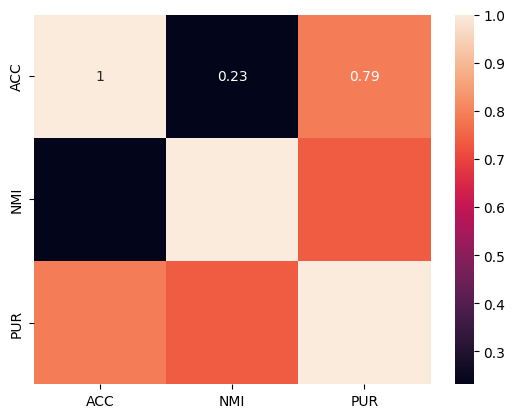

In [35]:
# plt.title('corrélation BagMCLES')
r=df_mcles.corr()[["ACC", "NMI", "PUR"]][:3]
sns.heatmap(r, annot=r.values)

On remarque :

* Une faible corrélation entre l'information mutuelle normalisé et l'exactitude
* Une corrélation relativement bonne entre la pureté et l'information mutuelle normalisé
* Une bonne corrélation entre l'exactitude et la pureté 

Corrélation entre hyper-paramètres et métriques

<Axes: >

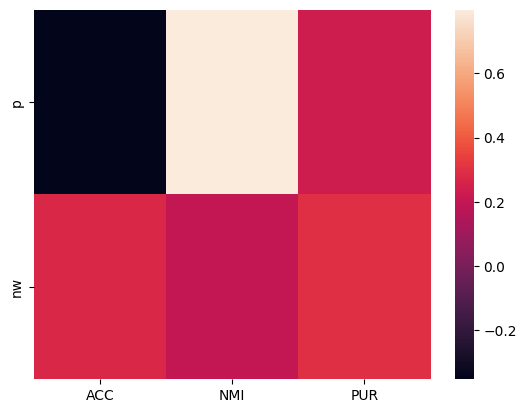

In [8]:
# plt.title('corrélation BagMCLES')
sns.heatmap(df_mcles.corr()[["ACC", "NMI", "PUR"]][3:])

Nous pouvons déjà remarquer qu'on a:

* Une bonne corrélation entre la taille des échantillons et l'information mutuelle entre les clusters construits et les groupes réels
* Une faible corrélation négative entre la taille des échantillons et l'exactitude du modèle
* Une corrélation malheureusement pas très grande entre le nombre de weak-learners et la qualité des clusters construits, mais plus prononcée avec 


#### Analyses du comportement des performances par rapport aux hyper-parmètres

Visualisations des performances en 3D

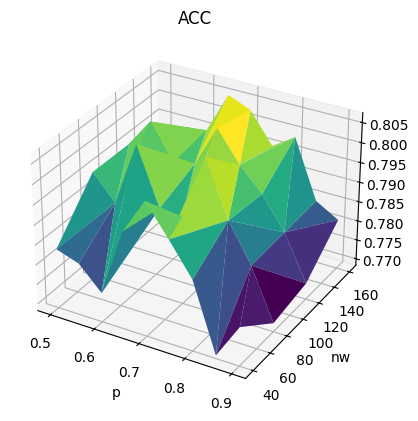

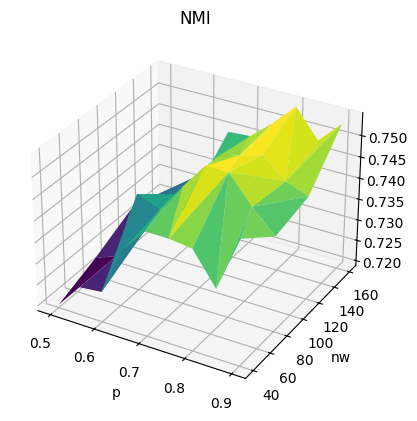

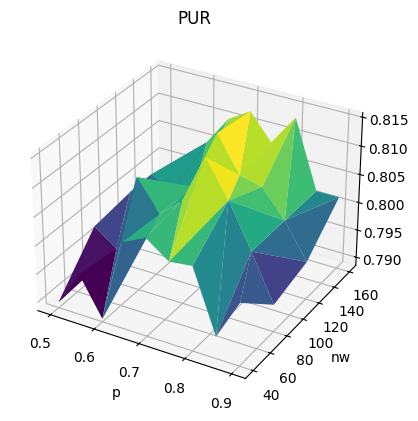

In [9]:
plot_metrics(df_mcles)

Projections 2D des visualisations 3D des performances

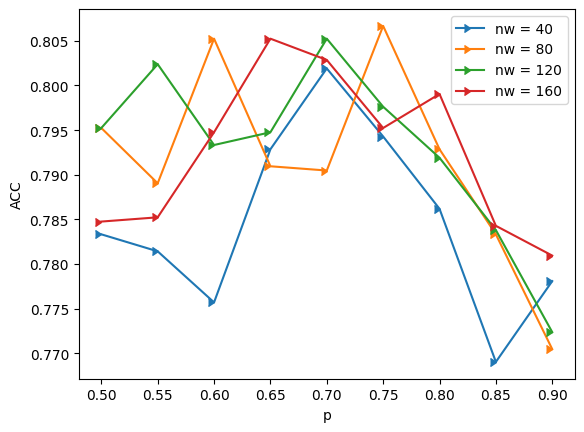

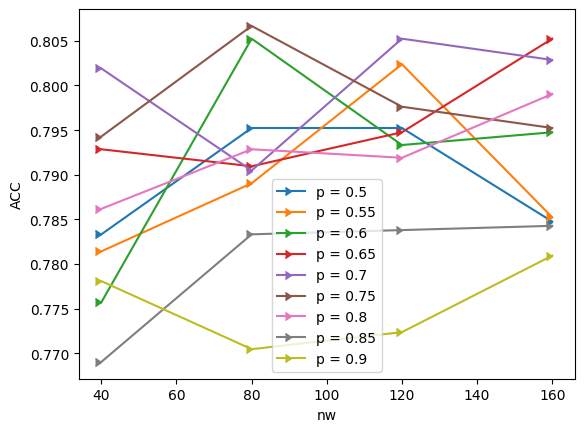

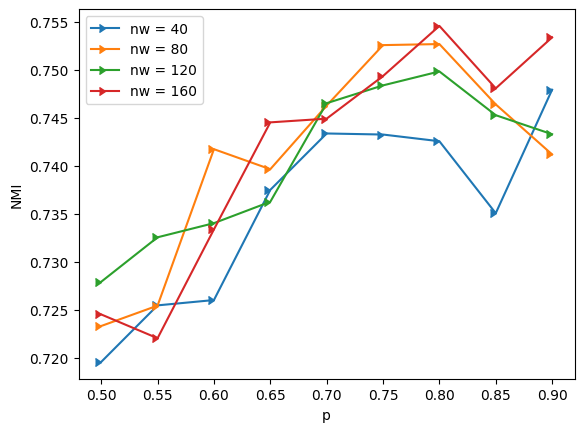

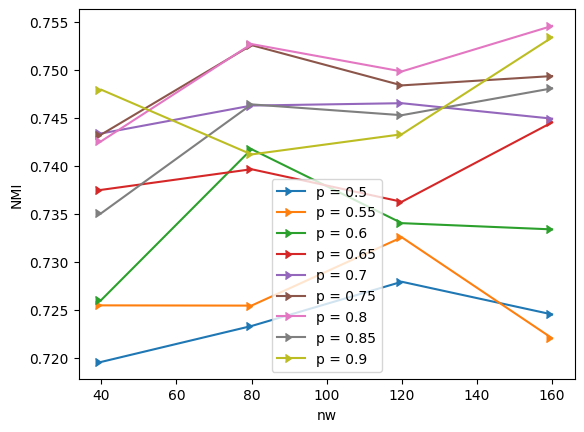

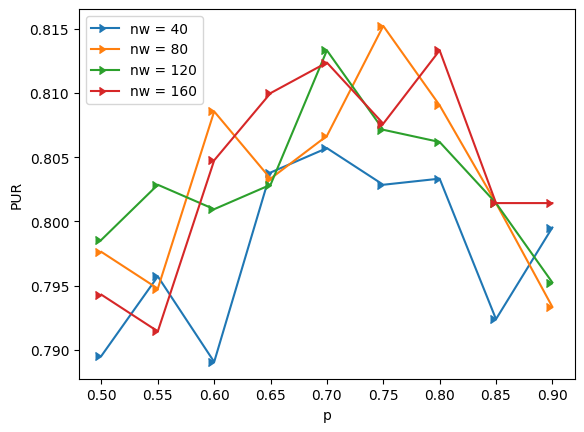

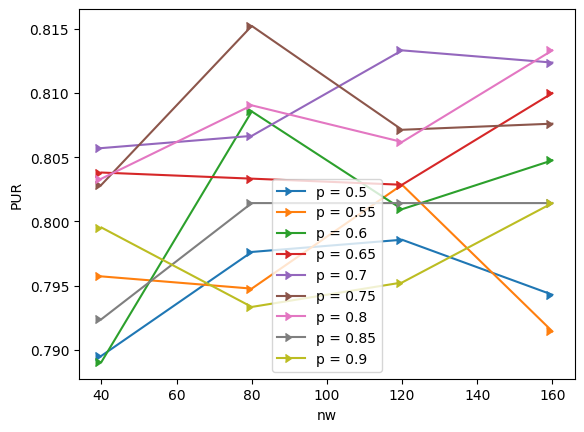

In [10]:
plot_fixed(df_mcles)

* Exactitude
  * projection 3D :
    le graphe de performance présente une courbe parabolique dépendant principalement de "p", où la zone de meilleures valeurs est décrite par des valeurs de "p" comprises entre 65% à 80%, et des valeurs de "nw" de plus de 100
  * projection 2D :
    * Cela se certifie avec les projections en 2D où on retrouve l'intervalle des valeurs de "p" donné de 65% à 80%
    * on observe également une légère hausse d'exactitude pour "p" allant de 50% à 80%, puis d'une forte baisse pour "p" à plus de 80% quelque soit les valeurs de "nw"
    * on remarque une tendance générale de hausse légère d'exactitude par rapport à "nw", avec de meilleures valeurs quand "p" est compris entre 60% et 80%
* Information mutuelle normalisée
  * projection 3D :
    on observe sur le graphe de performance que l'information mutuelle normalisée est fortement corrélée positivement à "p", plus "p" augmente, plus l'information mutuelle normalisée augmente. on remarque aussi que l'augmentation de "nw" conduit à une hausse plus légère d'elle (l'information mutuelle normalisée).
  * projection 2D :
    * on retrouve cette forte corrélation entre "p" et l'information mutuelle normalisée quelque soit les valeurs de "nw"
    * on retrouve comme pour l'exactitude une hausse légère de performance par rapport à "nw", avec des meilleures valeurs quand "p" est compris entre 70% et 80%
* Pureté
  * Projection 3D :
    on observe sur le graphe de performance comme pour celui de l'exactitude une courbe parabolique dépendant principalement de "p", avec la zone de meilleurs valeurs étant décrite par des valeurs de "p" comprises entre 65% à 75%, et des valeurs de "nw" de plus de 80
  * Projection 2D :
    * On revoit la parabole du graphe de performance où on observe par rapport à "p" une augmentation générale de la purété de 50% à 80% puis d'une forte baisse de 80% à plus quelque soit les valeurs de "nw"
    * On retrouve comme pour les autres métriques qu'il y'a une faible augmentation générale de la pureté par rapport à "nw", mais avec de meilleures valeurs avec "p" allant de 70% à 80% 


On peut voir que plus on augmente la taille des échantillons, plus on a tendance à avoir des clusters de moins en moins homogènes, qui respectent de moins en moins la constitution des groupes réels. Néanmoins, cela augmente les informations communes avec les groupes réels.
De plus, plus on augmente le nombre de weak-learners plus on construit de meilleures clusters.

On retrouve ainsi qu'il est conseillé d'utiliser `70% à 80%` des observations pour construire des échantillons et `le plus possible` de weak-learners dans le cas de MCLES.

In [11]:
pivot_tables(df_mcles, "mcles")

### Bagging MVGL

In [12]:
df_mvgl = df_mvgl[["ACC", "NMI", "PUR", "p", "nw"]]

#### Analyses de corrélation

In [13]:
df_mvgl.corr()

,ACC,NMI,PUR,p,nw
ACC,1.000000,0.314992,0.144117,-1.835354e-01,2.181057e-01
NMI,0.314992,1.000000,-0.451029,-7.165942e-01,2.949088e-01
PUR,0.144117,-0.451029,1.000000,8.842375e-01,1.542812e-01
p,-0.183535,-0.716594,0.884238,1.000000e+00,-2.563950e-17
nw,0.218106,0.294909,0.154281,-2.563950e-17,1.000000e+00


Correlation entre métriques

<Axes: >

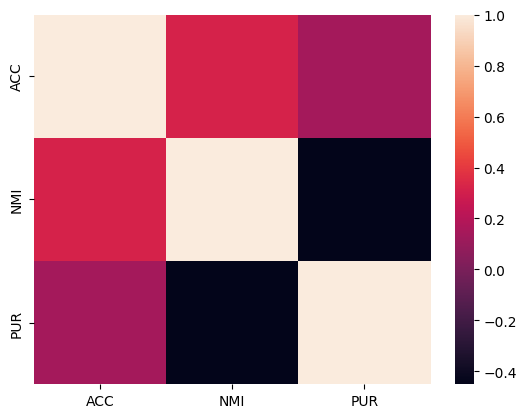

In [14]:
# plt.title('corrélation BagMCLES')
sns.heatmap(df_mvgl.corr()[["ACC", "NMI", "PUR"]][:3])

On observe :

* Une faible corrélation négative entre la pureté et l'information mutuelle normalisé
* Une faible corrélation positive entre la pureté et l'exactitude
* Une faible corrélation positive entre l'exactitude et l'information mutuelle normalisé

Corrélation entre hyper-paramètres et métriques

<Axes: >

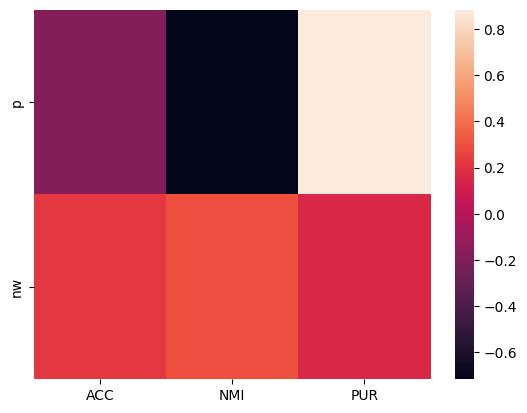

In [15]:
sns.heatmap(df_mvgl.corr()[["ACC", "NMI", "PUR"]][3:])

Nous remarquons qu'on a :
* comme pour le cas de `Bagging MCLES`, une corrélation malheureusement pas très grande entre le nombre de weak-learners et la qualité des clusters construits, mais cette fois il y'a plutôt une corrélation plus prononcée avec l'information mutuelle
* Une bonne corrélation entre la taille des échantillons et l'homogénéité des clusters construits par rapport à la réalité
* La taille des échantillons a une corrélation négative pas très forte avec l'exactitude du modèle et l'information mutuelle, néanmoins plus prononcée avec l'information mutuelle


#### Analyses du comportement des performances par rapport aux hyper-parmètres

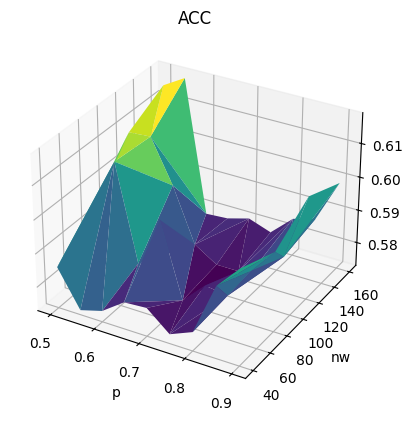

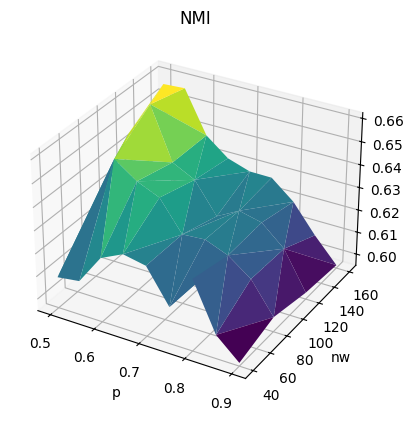

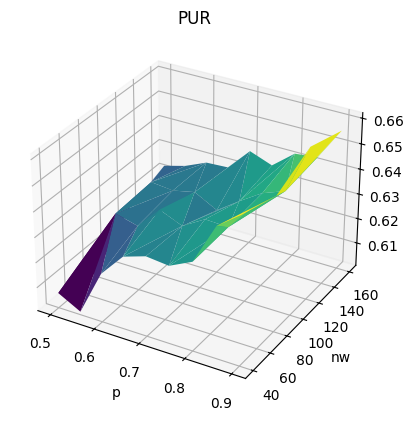

In [16]:
plot_metrics(df_mvgl)

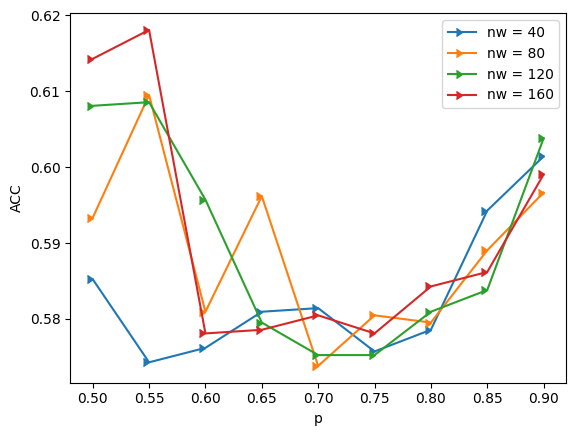

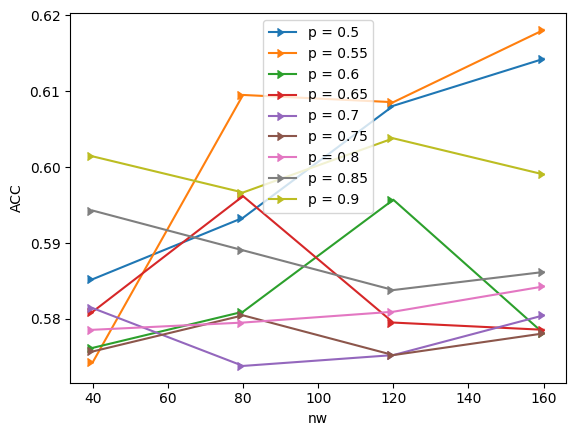

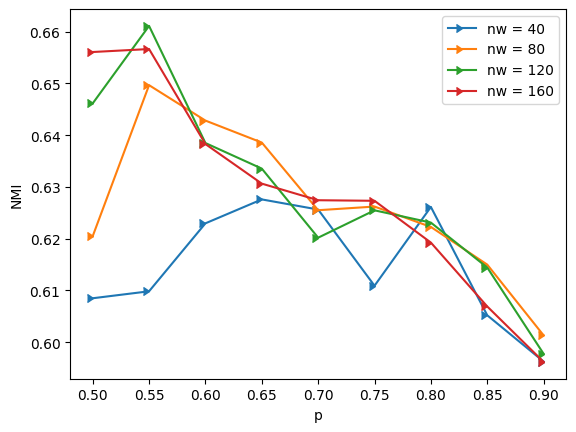

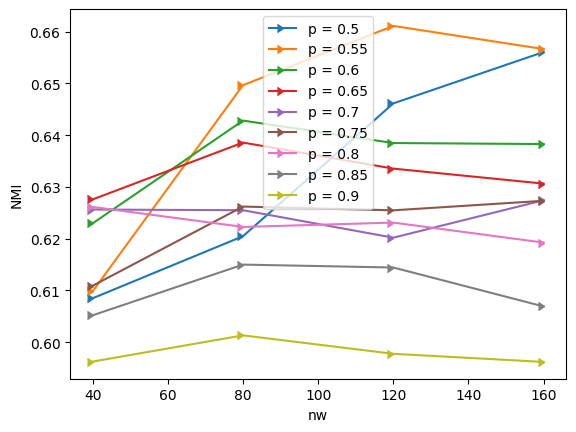

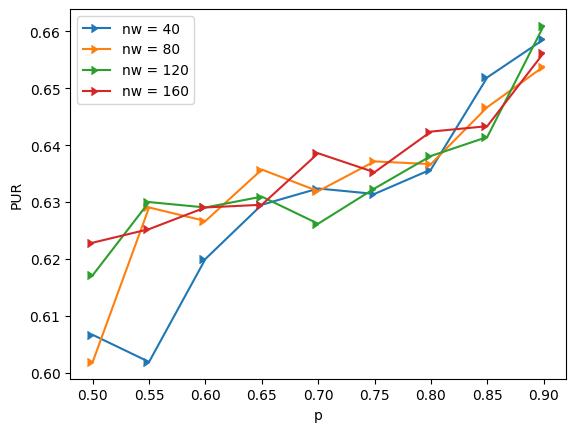

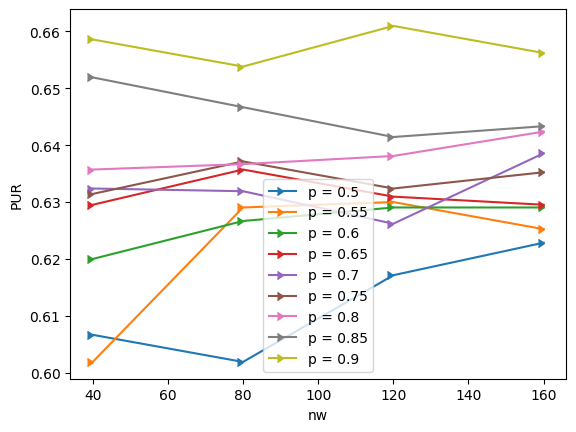

In [17]:
plot_fixed(df_mvgl)

* Exactitude
  * projection 3D :
    le graphe de performance présente une courbe parabolique dépendant principalement de "p", où la région de meilleures valeurs est décrite par des valeurs de "p" comprises entre 50% à 55%%, et des valeurs de "nw" de plus de 120
  * projection 2D :
    * Cela se certifie avec la projection en 2D où on retrouve l'intervalle des valeurs de "p" donné de 50% à 55%
    * on observe également une forte baisse d'exactitude pour "p" allant de 50% à 70%, puis hausse d'exactitude pour "p" de plus de 70% quel que soit les valeurs de "nw"
    * on remarque une forte hausse d'exactitude par rapport à "nw" quand "p" est compris entre 50% et 55%, mais une tendance plus légère pour des valeurs de "p" de plus de 55%
* Information mutuelle normalisée
  * projection 3D :
    on observe sur le graphe de performance que l'information mutuelle normalisée est fortement corrélée négativement à "p", plus "p" diminue, plus l'information mutuelle normalisée augmente. on remarque aussi que l'augmentation de "nw" conduit à une hausse plus légère d'elle (l'information mutuelle normalisée).
  * projection 2D :
    * on retrouve cette corrélation entre "p" et l'information mutuelle normalisée quelque soit les valeurs de "nw"
    * on retrouve comme pour l'exactitude une hausse légère de performance par rapport à "nw", avec des meilleures valeurs quand "p" est compris entre 50% et 55%
* Pureté
  * Projection 3D :
    on remarque sur le graphe de performance comme pour l'information mutuelle normalisée, qu'on a une forte corrélation positive entre la pureté et "p", plus "p" augmente, plus l'information mutuelle normalisée augmente. On peut de plus voir que l'augmentation de "nw" conduit à une hausse plus légère da pureté.
  * Projection 2D :
    * On revoit la corrélation par rapport à "p", où on a une augmentation générale de la purété qui devient plus forte lorsque "p" est supérieur à 80% quelque soit les valeurs de "nw"
    * on retrouve comme pour les autres métriques une hausse légère de performance par rapport à "nw", avec des meilleures valeurs quand "p" est a plus de 85%

On peut voir que plus on augmente la taille des échantillons, plus on a tendance à avoir des clusters de plus en plus homogène, mais qui respecte de moins en moins la constitution des groupes réels. De plus, cela réduit la quantité d’informations communes avec ces groupes réels.

Ce qui permet déjà d'observer une corrélation négative entre la pureté et les autres métriques.


On retrouve ainsi qu'il est conseillé d'utiliser `50% à 55%` des observations pour construire des échantillons et `le plus possible` de weak-learners dans le cas de MCLES.

In [18]:
pivot_tables(df_mvgl, "mvgl")

Ceci permet de monter que les algorithmes MCLES et MVGL ont peu de variance, MVGL en a moins par rapport à MCLES.

## Expérimentations finales

Grâce à nos analyses précédentes, nous avons sélectionné des valeurs par défaut des paramètres du modèle, pour la dataset `MSRC-V1` qui sont les suivantes

In [19]:
hyper_parametres = [
    {"model": "BagMCLES", "p": 0.7, "nw": 160},
    {"model": "BagMVGL", "p": 0.55, "nw": 160},
]

hyper_parametres = pd.DataFrame(hyper_parametres).set_index("model")
hyper_parametres.to_csv("results/hyper_parameters.csv")
hyper_parametres.to_latex("results/hyper_parameters.tex")
hyper_parametres

,p,nw
model,,
BagMCLES,0.70,160
BagMVGL,0.55,160


Ces paramètres nous ont permis de réaliser les expérimentations, dont les résultats ont été conservées

In [20]:
perfs = pd.read_csv("results/perfs.csv")

In [21]:
perfs = perfs.sort_values(["ACC", "NMI", "PUR"])[
    ["ACC", "ACC_std", "NMI", "NMI_std", "PUR", "PUR_std", "model"]
].set_index("model")
perfs

,ACC,ACC_std,NMI,NMI_std,PUR,PUR_std
model,,,,,,
mvgl,0.600000,0.000000,0.595783,0.000000,0.657143,0.000000
Bag_mvgl,0.615238,0.036418,0.643430,0.029070,0.623810,0.020203
mcles,0.720000,0.058041,0.718118,0.033318,0.755238,0.047676
Bag_mcles,0.801429,0.022941,0.743922,0.014258,0.811905,0.014639


Ce tableau nous permet de remarquer que:
* Le modèle d'apprentissage par ensemble est plus performant que les modèles de base
* Si les weak-learners sont très stables (suivant ces performances), le modèle le sera aussi mais moins fortement
* Si plutôt ils sont instables, le modèle sera encore plus stable


De ce fait, nous pensons qu'on pourrait également améliorer MCLES en utilisant un algorithme plus stable que Kmeans tel que GMM. On pourrait au-delà de changer Kmeans, l'introduire dans l'optimisation itérative des paramètres de MCLES, l'objectif étant d'augmenter la stabilité du modèle et les performances.

Au vue des observations, nous pouvons affirmer que l'objectif de la validation des hypothèses d'expérimentations a été atteint.